In [6]:
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing.pool import Pool
from albatross import Albatross
from optimiser import Optimiser

In [ ]:
bird = Albatross()

def single_optimisation(theta: float, V_ref: float,
                        initial_conditions: dict | None = None) -> float:
    optimiser = Optimiser(bird=bird, theta=theta, V_ref=V_ref,
                          initial_conditions=initial_conditions)
    optimiser.optimise()
    r = optimiser.sol.value(optimiser.v_avg)
    print(f"t = {theta}, obj={r}, V_ref={V_ref}")
    return r

def serial_polar_sweep(n_points: int, V_refs: list):
    thetas = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    results = []
    for V in V_refs:
        result = {"V_ref": V,
               "performances": [],
               "thetas": thetas}
        for t in thetas:
                print("theta = ", t)
                result["performances"].append(single_optimisation(theta=t, V_ref=V))
                print(r"v_avg = ", result["performances"][-1])
        results.append(result)
    return results

def parallel_polar_sweep(n_points:int, n_procs: int, V_refs: list):
    thetas = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    params = [(t, V) for V in V_refs for t in thetas]

    with Pool(n_procs) as pool:
        flat_results = pool.starmap(single_optimisation, params)

    results = []
    for i, V in enumerate(V_refs):
        start = i * n_points
        end = start + n_points
        results.append({
            "V_ref": V,
            "performances": flat_results[start:end],
            "thetas": thetas
        })
    return results

def coarse_sweep(n_coarse: int, V_ref: float) -> list[tuple[float, dict]]:
    thetas = np.linspace(0, 2*np.pi, n_coarse, endpoint=False)
    results = []
    for t in thetas:
        opt = Optimiser(bird=bird, theta=t, V_ref=V_ref)
        opt.optimise()
        results.append((t, opt.get_solution_dict()))
    return results

def find_nearest_ic(theta: float,
                    coarse_solutions: list[tuple[float, dict]]) -> dict:
    coarse_thetas = np.array([t for t, _ in coarse_solutions])
    # circular distance on [0, 2pi)
    diffs = np.abs(np.mod(coarse_thetas - theta + np.pi, 2*np.pi) - np.pi)
    idx = np.argmin(diffs)
    return coarse_solutions[idx][1]

def hot_start_polar_sweep(n_fine: int, n_coarse: int,
                           n_procs: int, V_refs: list) -> list[dict]:
    results = []
    for V in V_refs:
        # Phase 1: coarse serial sweep
        coarse_sols = coarse_sweep(n_coarse, V_ref=V)

        # Phase 2: build job list with pre-assigned ICs
        fine_thetas = np.linspace(0, 2*np.pi, n_fine, endpoint=False)
        params = [
            (t, V, find_nearest_ic(t, coarse_sols))
            for t in fine_thetas
        ]

        with Pool(n_procs) as pool:
            perfs = pool.starmap(single_optimisation, params)

        results.append({
            'V_ref': V,
            'thetas': fine_thetas,
            'performances': perfs,
        })
    return results

#V_refs = [15.0]
V_refs = [15.0, 17.5, 20.0]
#rs = serial_polar_sweep(60, V_refs)

#rs = parallel_polar_sweep(60, 8, V_refs)
rs = hot_start_polar_sweep(n_fine=240, n_coarse=12, n_procs=8, V_refs=V_refs)

t = 1.0471975511965976, obj=20.326423644318478, V_ref=15.0
t = 0.41887902047863906, obj=11.811727273339695, V_ref=15.0
t = 0.6283185307179586, obj=14.526158999195738, V_ref=15.0
t = 1.0733774899765125, obj=20.702647075864032, V_ref=15.0
t = 1.2566370614359172, obj=23.33314397971597, V_ref=15.0
t = 0.20943951023931953, obj=9.276782372548324, V_ref=15.0
t = 0.445058959258554, obj=12.141740302232977, V_ref=15.0t = 0.0, obj=6.945163067887467, V_ref=15.0

t = 0.6544984694978735, obj=14.874717431462727, V_ref=15.0t = 1.0995574287564276, obj=21.079433191629185, V_ref=15.0t = 0.02617993877991494, obj=7.224338326261377, V_ref=15.0


t = 0.47123889803846897, obj=12.474472165845583, V_ref=15.0
t = 0.8377580409572781, obj=17.37744309872755, V_ref=15.0
t = 1.2828170002158321, obj=23.67375714900064, V_ref=15.0
t = 0.4974188368183839, obj=12.809954750340884, V_ref=15.0
t = 1.1257373675363425, obj=21.456294556473296, V_ref=15.0
t = 0.23561944901923448, obj=9.583069414779176, V_ref=15.0
t = 0.052359877

In [ ]:
def symmetry_check(V_ref=15.0, test_thetas_deg=[45, 90, 135]):
    """Run θ and 2π−θ; results should agree within solver tolerance."""
    for deg in test_thetas_deg:
        t  = np.deg2rad(deg)
        tm = 2*np.pi - t
        a = single_optimisation(t,  V_ref)
        b = single_optimisation(tm, V_ref)
        print(f"θ={deg:3d}°: {a:.4f}   θ={360-deg:3d}°: {b:.4f}   diff={abs(a-b):.5f}")

symmetry_check()

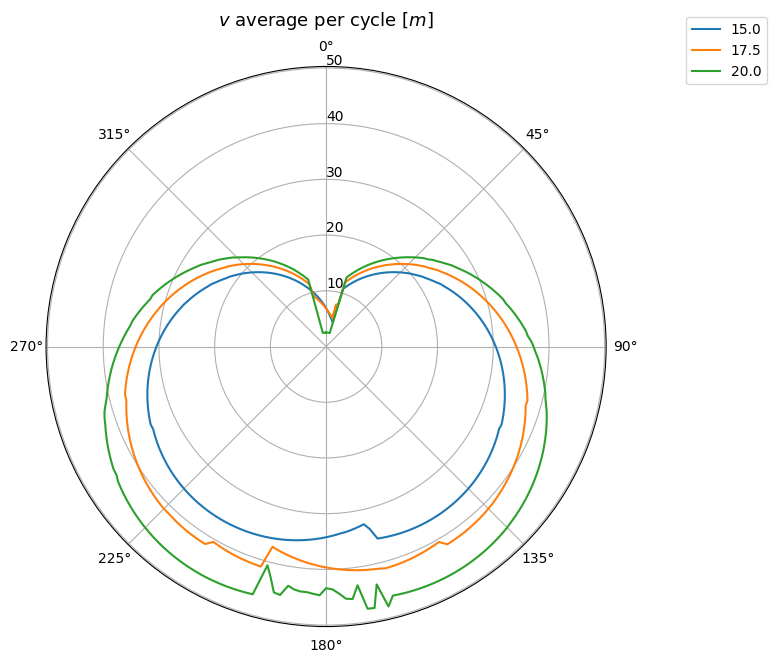

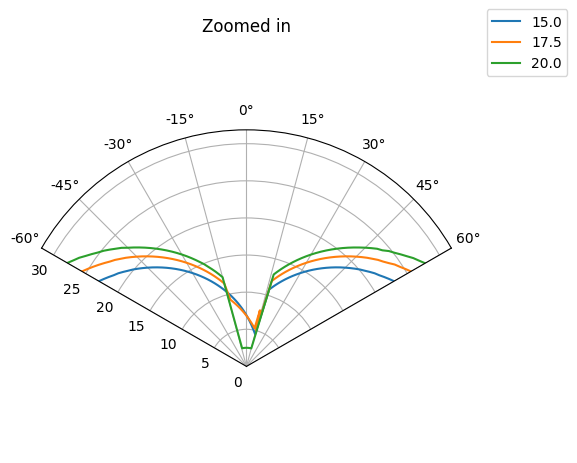

In [5]:
# full polar (original)
fig1, ax1 = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(8, 8))

for r in rs:
    ax1.plot(r['thetas'], r['performances'], label=str(r['V_ref']))

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title(r"$v$ average per cycle [$m$]", va="bottom", fontsize=13)
ax1.set_rlabel_position(0)
ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# zoomed polar: restrict to theta in [-pi/4, +pi/4] and sort angles
fig2, ax2 = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 6))
for r in rs:
    thetas = np.asarray(r['thetas'])
    perf = np.asarray(r['performances'])
    thetas_wrapped = (thetas + np.pi) % (2 * np.pi) - np.pi
    mask = np.abs(thetas_wrapped) <= (3*np.pi/8)
    sel_idx = np.where(mask)[0]
    sort_order = np.argsort(thetas_wrapped[sel_idx])
    ordered_thetas = thetas[sel_idx][sort_order]
    ordered_perf = perf[sel_idx][sort_order]

    ax2.plot(ordered_thetas, ordered_perf, label=str(r['V_ref']))

ax2.set_theta_zero_location("N")
ax2.set_theta_direction(-1)
ax2.set_title(r"Zoomed in", va="bottom", fontsize=12)
ax2.set_rlabel_position(0)
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax2.set_thetamin(-60)
ax2.set_thetamax(60)
plt.tight_layout()
plt.show()